In [1]:
from huggingface_hub import hf_hub_download
from ultralytics import YOLO
from dsa.constants import ROOT

/home/ajd/miniconda3/envs/data-snapshot/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load model
DOWNLOAD_PATH = ROOT / "models"
model_path = hf_hub_download(
    # repo_id="Armaggheddon/yolo26-document-layout",
    repo_id="Armaggheddon/yolo11-document-layout",
    filename="yolo11m_doc_layout.pt",
    repo_type="model",
    local_dir=DOWNLOAD_PATH,
)
model = YOLO(model_path)

# Inference
IMG_PATH = ROOT / "data/pages_cache/analyse_environnement_de_protection_des_regions_de_segou_san_v2_final.pdf_p002.png"
res = model.predict(IMG_PATH, imgsz=1280)
res


image 1/1 /home/ajd/data-snapshot-annotation/data/pages_cache/analyse_environnement_de_protection_des_regions_de_segou_san_v2_final.pdf_p002.png: 1280x992 2 List-items, 1 Page-footer, 7 Pictures, 2 Section-headers, 4 Texts, 111.5ms
Speed: 13.0ms preprocess, 111.5ms inference, 14.8ms postprocess per image at shape (1, 3, 1280, 992)


[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Caption', 1: 'Footnote', 2: 'Formula', 3: 'List-item', 4: 'Page-footer', 5: 'Page-header', 6: 'Picture', 7: 'Section-header', 8: 'Table', 9: 'Text', 10: 'Title'}
 obb: None
 orig_img: array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        ...,
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [25

In [3]:
res[0].names

{0: 'Caption',
 1: 'Footnote',
 2: 'Formula',
 3: 'List-item',
 4: 'Page-footer',
 5: 'Page-header',
 6: 'Picture',
 7: 'Section-header',
 8: 'Table',
 9: 'Text',
 10: 'Title'}

In [4]:
res[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([9., 9., 6., 6., 9., 7., 4., 7., 3., 6., 3., 6., 9., 6., 6., 6.], device='cuda:0')
conf: tensor([0.9749, 0.9710, 0.9609, 0.9577, 0.9508, 0.8726, 0.6980, 0.5446, 0.4118, 0.3619, 0.3459, 0.3325, 0.3271, 0.3233, 0.3070, 0.2640], device='cuda:0')
data: tensor([[3.0122e+02, 5.4414e+02, 2.2497e+03, 9.1008e+02, 9.7491e-01, 9.0000e+00],
        [3.0024e+02, 1.6721e+03, 2.2507e+03, 2.0382e+03, 9.7102e-01, 9.0000e+00],
        [2.9667e+02, 2.1008e+03, 2.1209e+03, 2.6205e+03, 9.6088e-01, 6.0000e+00],
        [3.0011e+02, 9.7446e+02, 2.2513e+03, 1.5992e+03, 9.5775e-01, 6.0000e+00],
        [2.9968e+02, 2.6886e+03, 2.2499e+03, 2.8604e+03, 9.5077e-01, 9.0000e+00],
        [2.9883e+02, 4.2954e+02, 9.7551e+02, 4.7575e+02, 8.7265e-01, 7.0000e+00],
        [2.2267e+03, 3.1011e+03, 2.2638e+03, 3.1473e+03, 6.9803e-01, 4.0000e+00],
        [4.8196e+02, 3.0710e+02, 1.3291e+03, 3.5976e+02, 5.4461e-01, 7.0000e+00],
        [5.5477e+02, 2.93

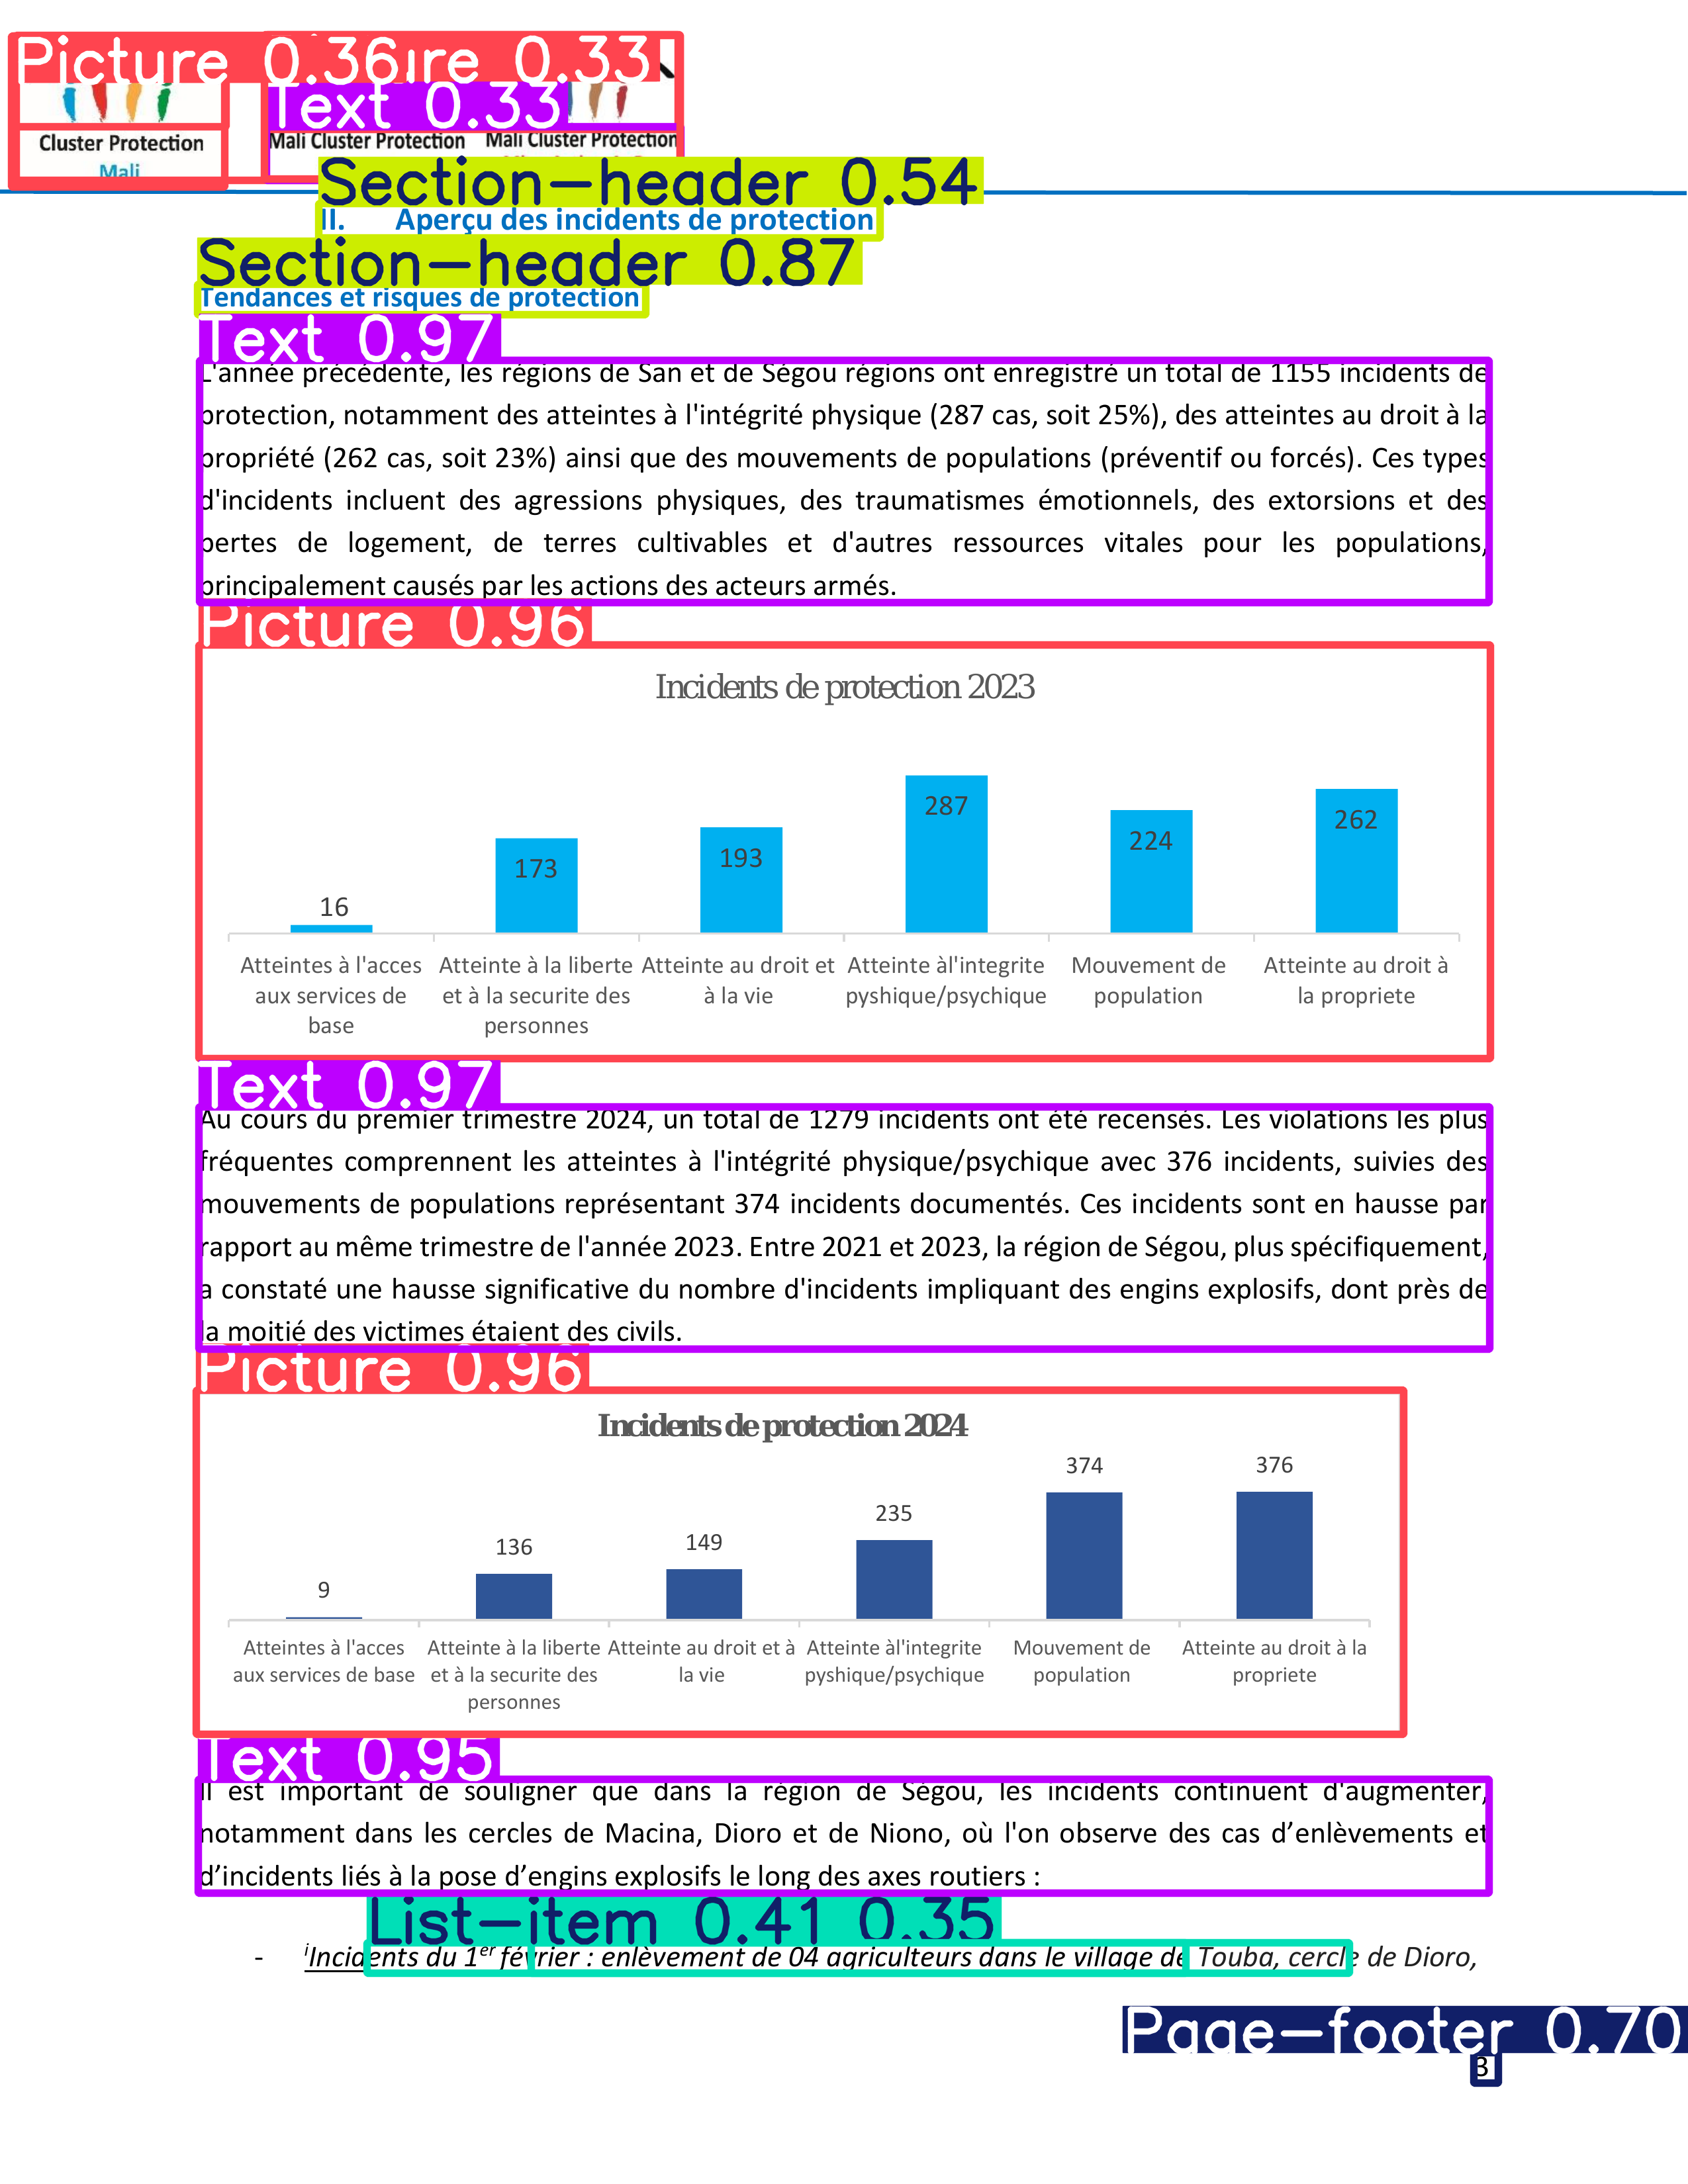

In [5]:
res[0].show()